Generating the positioning the GNSS
Author: Brandon Engelbrecht

NOTE:
    We make use of the MeerKAT/meerkat_utils package found on GH and owned by Dr. Yi-Chao Li

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../param_import/')
# Import list
from imports import *
# Parameter list
import param_multi_mask as pm
from itertools import cycle
import random

### -------------------------------------------- Satellite Position--------------------------------------------

In [3]:
# Returning the date/time of observation or unix time
fname, dtime = tools.timepoint(fname = pm.file, date = None)

# Checking the location for the two-line-element files
tle_location = tools.tle_download(
    tle_load = 'TLE/2019_02_21_tle/', direc_path=None
)

# Location of saved data
dsave = pm.data_save+str(fname)+'/'

# Location of saved figures
dfigures = pm.data_save+str(fname)+'/figures/'

# Beam model
beam_model = pm.beam_model

# Initalizing of the satellite position [Check_satellite]
tsc = cs.Telescopesite_Satellite_Catalogue(
    source_url = tle_location, 
    sats_type = pm.satellite_type,
    reload = False)

# Start of observation time [AUTOMATIC]
start_observation_time = int(fname)+pm.nd_s0[0]
observation_time_list = (pm.nd_s0 -pm.nd_s0[0]) * u.second
telescope_location = [pm.telescope_Lat* u.deg , pm.telescope_Lon* u.deg]

# Telescope pointing array in Az and Alt
telescope_pointing =  np.array(
    [
        [pm.nd_s0_coords[0][i], pm.nd_s0_coords[1][i]] for i in range(len(pm.nd_s0_coords[0]))
    ]
)


Date of observation: 2019-02-25 02:40:11
Fname: 1551055211
Two Line Element location: TLE/2019_02_21_tle/
load sat catalogue from TLE/2019_02_21_tle/ gps-ops.txt
load sat catalogue from TLE/2019_02_21_tle/ glo-ops.txt
load sat catalogue from TLE/2019_02_21_tle/ galileo.txt
load sat catalogue from TLE/2019_02_21_tle/ beidou.txt
load sat catalogue from TLE/2019_02_21_tle/ irnss.txt
load sat catalogue from TLE/2019_02_21_tle/ sbas.txt
load sat catalogue from TLE/2019_02_21_tle/ qzs.txt


In [4]:
# Running
tsc.obs_time= datetime.utcfromtimestamp(
    start_observation_time).strftime('%Y-%m-%d %H:%M:%S'
                                    )
tsc.obs_time_list = observation_time_list
tsc.obs_location = telescope_location
tsc.get_sate_coords()

# Constellations that remains behind
cons_remain = tsc.sats_type_remain

# Position of satellites with respect to MeerKAT pointing
satellite_angle = tsc.check_angular_separation(
    pointings = telescope_pointing, 
    max_angle = 100, 
    beam_func = None, 
    ymin = 1e-10, 
    ymax = 1,
    axes=None
)

# Transposing the angular seperation values to allow for better plotting
satellite_angle_t = [satellite_angle[con].T for con in range(len(cons_remain))]

Time range 2019-02-25 00:53:05.000 - 2019-02-25 02:28:04.589
Satellite      gps-ops has   15 satellites  [use   5.97 s]
Satellite      glo-ops has   13 satellites  [use   4.90 s]
Satellite      galileo has   13 satellites  [use   5.00 s]
Satellite       beidou has   18 satellites  [use   7.33 s]
Satellite        irnss has    5 satellites  [use   2.83 s]
Satellite         sbas has    9 satellites  [use   4.51 s]
Satellite          qzs has    0 satellites [Removing this constellation from sats_type]


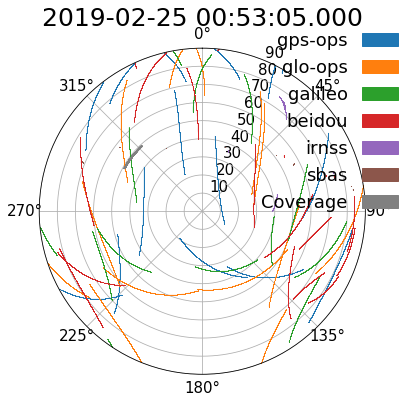

358


In [5]:
# Plotting the spherical observation of the satellites
tsc.check_altaz()

# Replace the string of constellations remain
tools.string_replacer(
    filePath = '../param_import/param_multi_mask.py', 
    str_to_change = 'constellations_remain = [', 
    new_str = 'constellations_remain = ' + str(cons_remain) + '\n'
)

### Satellite angular observations

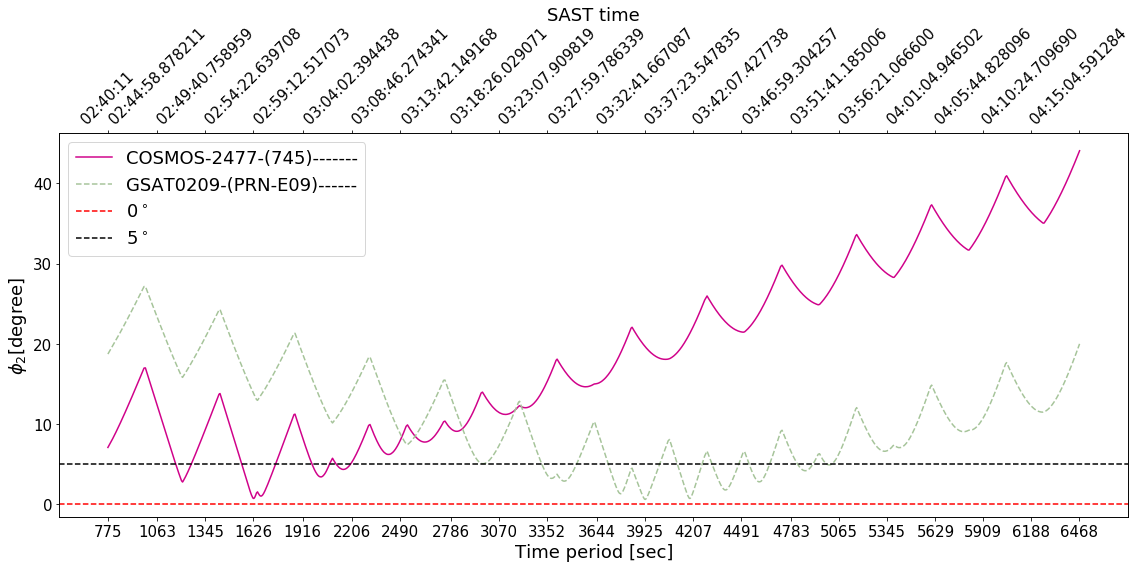

In [6]:
if len(pm.satellite_type)>1:

    angle_dis=5
    sat_below_coords = []
    sat_below_cons = []
    sat_below_name = []
    for ci in range(len(tsc.sats_type_remain)):
        sat_below_idx = np.unique(np.ma.where(satellite_angle_t[ci] < angle_dis)[0])
        if len(sat_below_idx) > 0:
            for si in sat_below_idx:
                sat_below_cons.append(tsc.sats_type_remain[ci])
                sat_below_coords.append(satellite_angle_t[ci][si])
                sat_below_name.append(tsc.name_list[0][ci][si])

    dtimes = [
        datetime.strptime(
            dtime, '%Y-%m-%d %H:%M:%S'
        ) + timedelta(
            seconds = tsc.obs_time_list[0].value[i]) for i in range(len(tsc.obs_time_list[0].value))]
    
    
    dtimes_idx = np.arange(0, len(dtimes), np.round(len(dtimes)/20))

    fig, axs = plt.subplots(figsize=(16, 8) , nrows=1, ncols=1)
    ax = axs

    lines = ["-","--","-.",":"]
    linecycler = cycle(lines)

    no_of_colors=len(sat_below_name)
    color_choice=["#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)]) for j in range(no_of_colors)]

    for si,sat_list in enumerate(sat_below_coords):
        ax.plot(observation_time_list.value + pm.nd_s0[0], sat_list, color=color_choice[si], linestyle=next(linecycler), label=sat_below_name[si])


    ax.axhline(0, color='red', linestyle='--', label= r'$0^\circ$')
    ax.axhline(5, color='black', linestyle='--', label= r'$5^\circ$')

    ax.set_xticks([observation_time_list.value[i] + pm.nd_s0[0] for i in dtimes_idx])
    ax.set_xlabel('Time period [sec]')
    ax.set_ylabel(r'$\phi_2$[degree]')  
    ax.legend(frameon=True, loc='best', ncol=1)#  bbox_to_anchor=(1, 1.))

    # ax.set_xlim(57600, 69120)

    local_ticks = ax.get_xticks().tolist()
    labels = [str(dtimes[i])[11:] for i in dtimes_idx]

    ax2 = ax.twiny()
    # plt.sca(ax2)
    ax2.set_xlabel('SAST time')
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(local_ticks)
    ax2.set_xticklabels(labels, rotation=45)


    fig.tight_layout()
    plt.show()

In [7]:
sat_below_coords_idx = [np.ma.where(sat_below_coords[i] < 5)[0] for i in range(len(sat_below_coords))]

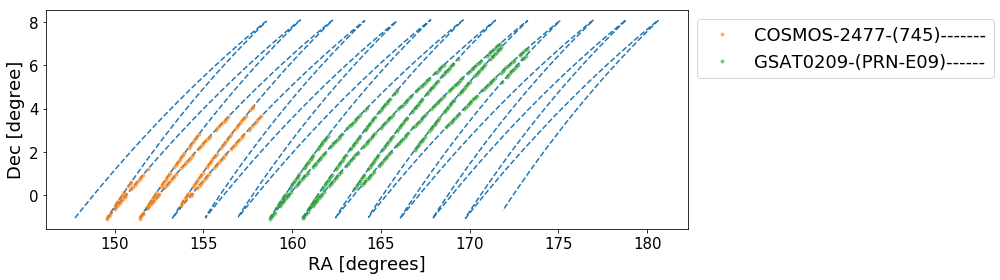

In [8]:
ra_m = pm.nd_s0_coords2[0]
ra_dec = pm.nd_s0_coords2[1]

fig, axs = plt.subplots(figsize=(14,4))
ax=axs
ax.plot(ra_m, ra_dec, '--')

for posi, pos_el in enumerate(sat_below_coords_idx):
    ax.plot(ra_m[pos_el], ra_dec[pos_el], '.', alpha=0.5,label=sat_below_name[posi])


ax.set_xlabel('RA [degrees]')
ax.set_ylabel(r'Dec [degree]') 
ax.legend(frameon=True, loc='best', ncol=1,  bbox_to_anchor=(1, 1.))


fig.tight_layout()

In [9]:
sat_below = {
    'constellation':sat_below_cons,
    'angle_sep':sat_below_coords,
    'sat_names':sat_below_name}

# Saving function
# pickle.dump(sat_below, open(pm.data_save+'nearby_satellites/sats_under_5.p', 'wb'))

In [10]:
sat_ang_times = []
for ti in range(5):
    sat_times = []
    # print (5-ti)
    for sat_i in range(len(tsc.sats_type_remain)):
        try:
            sat_ang = np.ma.where(
                np.ma.logical_and(
                    satellite_angle_t[sat_i] >= 4-ti, satellite_angle_t[sat_i] <= 5-ti
                )
            )[1]
            
            if len(sat_ang) != 0:
                sat_times.append(sat_ang)
        except ValueError:
            continue
    sat_times = np.concatenate((sat_times))
    # print(sat_times)
    sat_ang_times.append(sat_times)


### Functions

In [11]:
def constellation_seperation_plot(constellation, cons_position, time, date, save=False):
    '''
    Representing the angular seperation of different constellations to the MeerKAT pointing
    Parameters:
        constellation-list of constellations names
        cons_position-list of constellations containing individual satellite poisitons for a given time
        time-list of timestamps. NB: should be the same length as an individual satellite in the list
        date-date/time of the first point in the constellation
        save-file to save the information, should be the path/extenstion
    '''
    
    if len(constellation)==1:
        fig_w, fig_l = 8, 4
        nrow, ncol = 1,1
    else:
        fig_w, fig_l = 5*len(constellation), 2*len(constellation)
        nrow, ncol = int(np.ceil(len(constellation)/2.)), int(np.ceil(len(constellation)/3.))
        
    
    fig, axs = plt.subplots(figsize=(fig_w, fig_l) , nrows=nrow, ncols=ncol)
    # fig.suptitle(date+'-[GMT] constellation with respect to MeerKAT pointing', y=1.03)
    if len(constellation)==1:
        ax=axs
        ax.set_title(constellation)
        for sat_list in cons_position[0]:
            ax.plot(time, sat_list)
            ax.axhline(0, color='red', linestyle='--', label= '0 degree')
            ax.axhline(5, color='black', linestyle='--', label= '5 degree')

    
    else:
        for cidx, con in enumerate(constellation):
            if cidx<int(np.ceil(len(constellation)/2.)):
                row_idx, col_idx = cidx, 0,
            else:
                row_idx, col_idx = cidx-int(np.ceil(len(constellation)/2.)), 1

            ax=axs[row_idx, col_idx]
            ax.set_title(con)
            for sat_list in cons_position[cidx]:
                ax.plot(time, sat_list)
            ax.axhline(0, color='red', linestyle='--', label= '0 degree')
            ax.axhline(5, color='black', linestyle='--', label= '5 degree')
        
            ax.set_xlabel('Time period [sec]')
            ax.set_ylabel(r'$\phi_2$[degree]')  
            ax.legend(loc='upper right')


    fig.tight_layout()
    
## ------------------------------------------------------------------------------------------------------------------

def nearby_satellite_idx(constellation, cons_position, angle, fill_in=False, save_idx=False, save_path=None):
    '''
    For a given angle, the function determins all satellites that pass the given angle. 
    Returns the indicies for the pass.
    cosntellation-list of constellation names
    cons_position-list of cosntellations containing individual satellite positions for a given time
    angle-angular distance from the pointing to the satellite
    fill_in-default False, if True will collect all indices of first entry to last exit of satellites
    save_idx-default Flase, if True, indices will be saved
    save_path-if save_idx==True then provide path to save the satellite indices
    '''
    
    con_time_idx =[{constellation[sat]:np.ma.where(cons_position[sat] < angle)[1]} for sat in range(len(cons_position))]
    # Get rid of the list and work with a dicitonary only
    con_idx = {}
    for dval in con_time_idx:
        con_idx.update(dval)

    if fill_in==True:
        for keys in con_idx.keys():
            if len(con_idx[keys])!=0:
                con_idx[keys]=np.array([val for val in range(con_idx[keys][0], con_idx[keys][-1]+1, 1)])
                
    if save_idx==True:
        if os.path.exists(save_path)!=True:
            print ('Save path does not exist creating')
            os.mkdir(save_path)
        else:
            print ('Path exists')
        if fill_in==True:
            pickle.dump(con_idx, open(save_path+'nearby_satellite_close_angle_'+str(angle)+'F.p', 'wb'))
        else:
            pickle.dump(con_idx, open(save_path+'nearby_satellite_close_angle_'+str(angle)+'p', 'wb'))
            
    return con_idx

## ------------------------------------------------------------------------------------------------------------------

# Function for multiple observation days [WORK IN PROGRESS]
# 1. Want to make this function generic, feed it new strategies based on different days, different times, feed it any observation point
def observation_window_same_time(first_date, last_date, start_time):
    '''
    Returns the different start days for an observation, given the initial date to the final date and
    using the time same that should be run for all those dates.
    date format: YYYY-MM-DD
    time_format: hh:mm:ss
    first_date-First day of observation
    last_date-Last day of observation
    start_time-Starting time of each observation
    '''
    
    sdate = datetime.strptime(first_date, "%Y-%m-%d")
    edate = datetime.strptime(last_date, "%Y-%m-%d")

    delta = edate - sdate 
    stime = datetime.strptime(start_time, '%H:%M:%S')
    stime_delta = timedelta(
        hours = stime.hour, 
        minutes = stime.minute, 
        seconds = stime.second
    )

    windows = []
    for i in range(delta.days + 1):
        observation_start = sdate + timedelta(days=i) + stime_delta
        windows.append(observation_start.strftime("%Y-%m-%d %H:%M:%S"))

    return np.array(windows), stime.strftime("%H:%M:%S")


def multiple_observations(window, constellations, timestamps, show=False):
    '''
    Showing multple bservations for the given days and times.
    window-the observation window, a list of times for the observation
    constellations-which constellations are required for this observation 
    timestamps-list of time values for the observation
    
    !!! Function still needs more generic-ness
    '''

    window, start_time = window
    
    # Initalizing the time
    mo_tsc = cs.Telescopesite_Satellite_Catalogue(
        source_url = tle_location,
        sats_type = pm.satellite_type,
        reload = False
    )
    
    mo_tsc.obs_location = [pm.telescope_Lat* u.deg , pm.telescope_Lon* u.deg]
    telescope_pointing =  np.array(
        [
            [pm.nd_s0_coords[0][i], pm.nd_s0_coords[1][i]] for i in range(len(pm.nd_s0_coords[0]))
        ]
    )

    # Constellation name and satellite angles
    obs_time_window_sats = []    
    obs_time_window_cons = []

    # Running for each observation window
    for i in window:
        mo_tsc.obs_time =i
        mo_tsc.obs_time_list = timestamps * u.second

        mo_tsc.get_sate_coords()

        # Calculationg the satellite angle
        satellite_angle = mo_tsc.check_angular_separation(
            pointings = telescope_pointing,
            max_angle = 100,
            beam_func = None,
            ymin = 1e-10,
            ymax = 1,
            axes = None
        )
        
        # Transposing the angular seperation values to allow for better plotting
        satellite_angle_t = [satellite_angle[con].T for con in range(len(constellations))]
                                                
        obs_time_window_cons.append(constellations)
        obs_time_window_sats.append(satellite_angle_t)

    print ('Done')
    obs_time_window_sats = np.array(obs_time_window_sats)
    
    # Plotting componant
    if show == True:
        fig, axs = plt.subplots(
            obs_time_window_sats.shape[0], 
            obs_time_window_sats.shape[1],
            sharex = True, 
            sharey = True, 
            figsize = (10*obs_time_window_sats.shape[0], 5*obs_time_window_sats.shape[0]))
        
        
        fig.suptitle(str(obs_time_window_sats.shape[0])+'-Day of observation @ '+start_time, y=1.01, fontsize=28)

        # Looping through different constellations
        for constellation in range(obs_time_window_sats.shape[1]): 

            for timeline in range(obs_time_window_sats[:, constellation].shape[0]):
                # If any satellites within a constellation goes closer than 5 degrees will highlight the plot yellow-orange
                if len(np.ma.where(obs_time_window_sats[timeline,constellation] < 5)[0]) !=0:
                    axs[timeline, constellation].set_facecolor('xkcd:yellow orange')
                    axs[timeline, constellation].patch.set_alpha(0.2)
                # If any satellites within a constellation goes closer than 1 degrees will highlight the plot pale red
                elif len(np.ma.where(obs_time_window_sats[timeline,constellation] < 1)[0]) !=0:
                    axs[timeline, constellation].set_facecolor('xkcd:pale red')
                    axs[timeline, constellation].patch.set_alpha(0.2)
                # Otherwise green
                else:
                    axs[timeline, constellation].set_facecolor('xkcd:pale green')
                    axs[timeline, constellation].patch.set_alpha(0.2)



                for sat in range(obs_time_window_sats[timeline, constellation].shape[0]):
                    axs[timeline, constellation].plot(timestamps, obs_time_window_sats[timeline, constellation][sat])          

                    axs[timeline, constellation].axhline(0, color='red', linestyle='--', label= '0 degree')
                    axs[timeline, constellation].axhline(5, color='black', linestyle='--', label= '5 degree')

                    axs[0, constellation].set_title(constellations[constellation], rotation=0, fontsize=20, weight="bold")
                    axs[timeline, 0].set_ylabel(window[timeline]+'\nAngular Seperation [Deg]', rotation=90,fontsize=15)
                    axs[-1, constellation].set_xlabel('Time [sec]', rotation=0, fontsize=15)

        plt.tight_layout()
        plt.show()
        
        
## ------------------------------------------------------------------------------------------------------------------

# Function for the satellite gain with repsect to the telescope beam
def satellite_telescope_beam(frequency, pointings, beam_choice=None, close_angle=None):
    '''
    Produces the constellation gain plots with respect to the position of the satellites and telescope beam choice.
    frequency-a list of frequency values
    pointings-list of positional pointings for the telecope
    beam_choice-str, a choice of 3 beam models: [eidos, cosine, emss]
    '''
    
    if beam_choice=='eidos':
        beam_func = bm.Khans_beam_model(f=frequency)
    elif beam_choice=='cosine':
        beam_func = bm.Cosine_beam_model(f=frequency)
    elif beam_choice=='emss':
        beam_func = bm.emss_beam_model(f=frequency)
        
    else: 
        print ('Incorrect beam choice given')
    
    stype, sname, stemperature = [], [], []
    for _sat_info in tsc.itersats_temperature(
        pointings = pointings, 
        beam_func = beam_func, 
        close_angle = close_angle):
        
        _sat_type, _sat_names, _temperature = _sat_info
        print 'Sat. Name includes %s ...'%_sat_names[0] 
        print 'N_freq x N_time x N_sats = %d x %d x %d '%_temperature.shape

        np.array(stype.append(_sat_type)), 
        sname.append(_sat_names) 
        stemperature.append(np.sum(_temperature[:,:,:], axis=2))
        
        del _temperature 
        
    return stype, sname, np.array(stemperature)

## ------------------------------------------------------------------------------------------------------------------
# Function for plotting
def satellite_telescope_beam_plot(gtemperature):
    '''
    Returns the gain power plots for the different constellation based on the results from satellite_telescope_beam
    gtemperature - gain power for the various cosntellations
    
    '''
    fig, axs = plt.subplots(
        figsize = (20,8),
        nrows = int(np.ceil( len(stemperature)/2) ),
        ncols = int(np.ceil( len(stemperature)/3) ),
        sharey = True
    )
    
    fig.suptitle('Telescope gain of constellations with respect to telescope pointing', y=1.04)
    
    return

## ------------------------------------------------------------------------------------------------------------------

# Function for the determining the frequency band of choice
def frequency_band_list(frequency=pm.frequency, fstart=pm.fs, fend=pm.fe):
    """
    Returns the frequency band for the given start and end points in freqeuncy 
    frequency-list of frequency values
    fstart-starting frequency value
    fend-end frequency value
    """
    if fstart and fend is not None: 
        channel_start_idx = (np.where(frequency > fstart)[0][0])
        channel_end_idx = (np.where(frequency > fend)[0][0]) 
        frequency_band = frequency[channel_start_idx-1:channel_end_idx+1]

    elif fs is None and fe is not None:
        channel_start_idx = 0
        channel_end_idx = (np.where(frequency > fend)[0][0]) 
        frequency_band = frequency[channel_start_idx:channel_end_idx+1]


    elif fstart is not None and fend is None:
        channel_start_idx = (np.where(frequency > fstart)[0][0])
        channel_end_idx = -1
        frequency_band = frequency[channel_start_idx-1:channel_end_idx]

    else:
        frequency_band = frequency[0:-1]

    return frequency_band



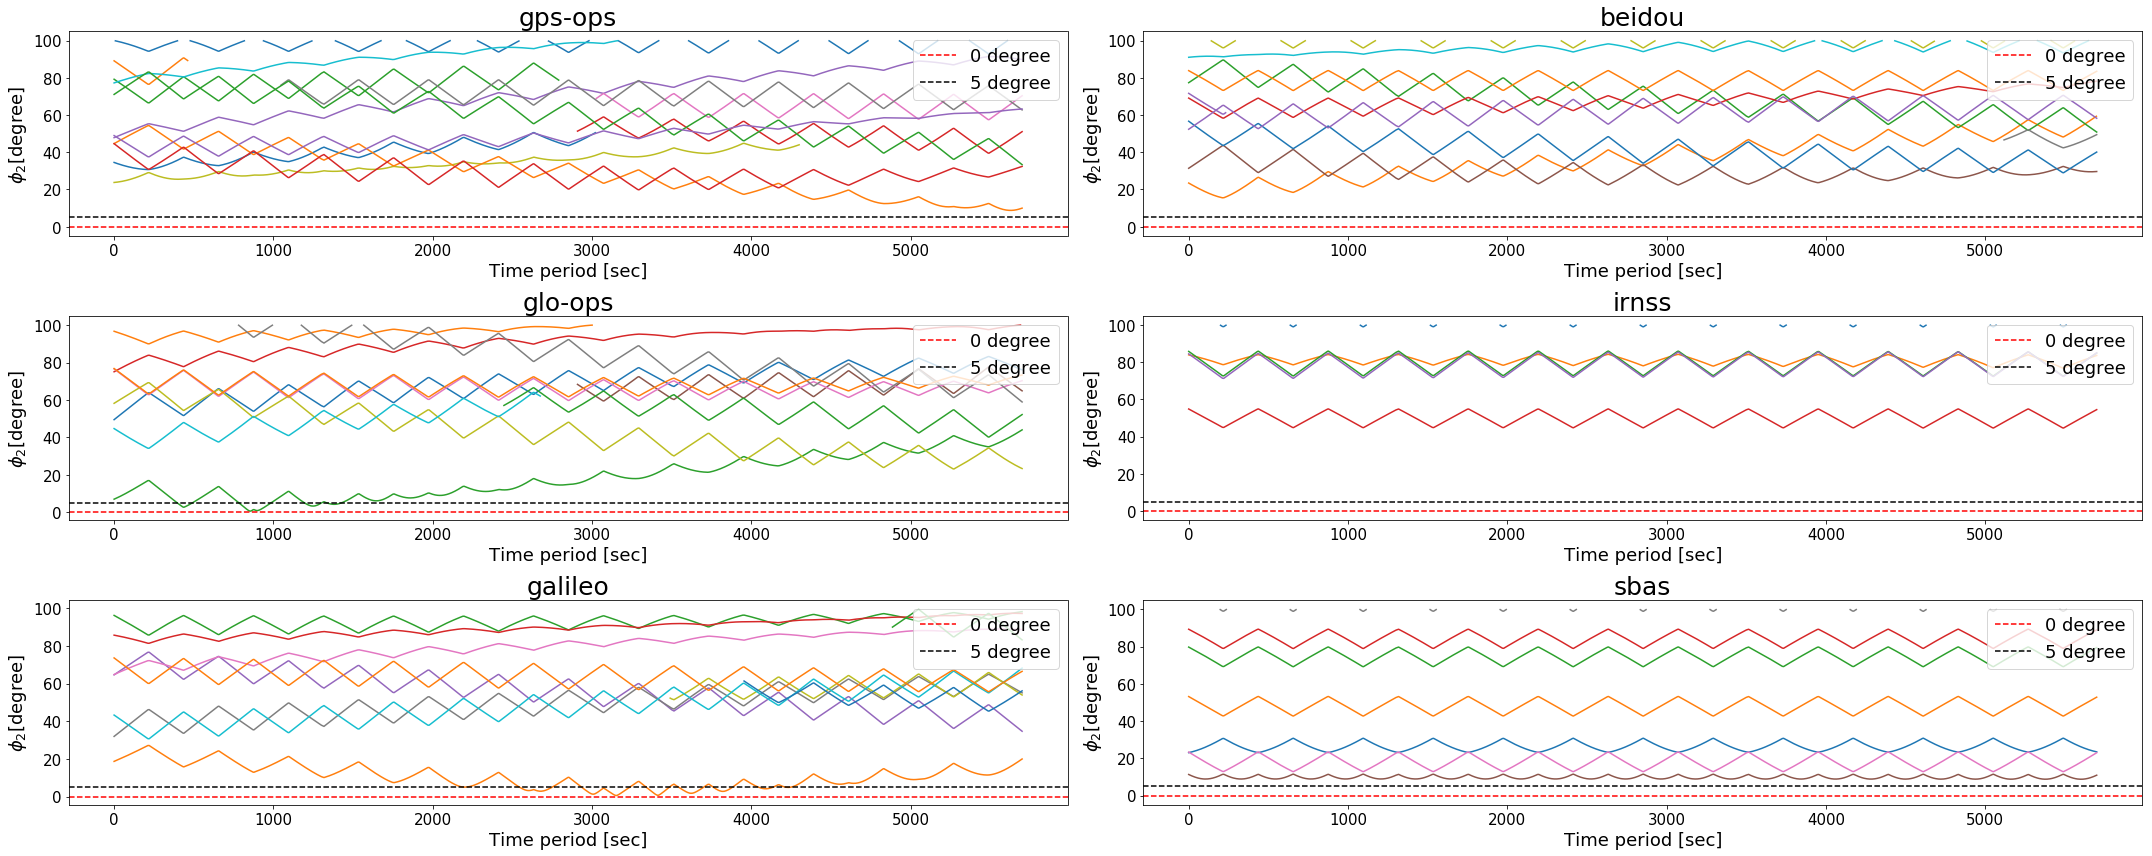

In [12]:
constellation_seperation_plot(constellation=cons_remain, cons_position=satellite_angle_t, time=observation_time_list.value, date=observation_time_list.value[0], save=False)

### Excecuting

In [13]:
# Obtaining the indices of constellations that approach within an angular distance of the pointing of the telescope
for i in range(1, 6):
    nearby_satellite_idx(
        constellation = cons_remain, 
        cons_position = satellite_angle_t, 
        angle = i,
        fill_in = True,
        save_idx = True, 
        save_path = pm.data_save+'nearby_satellites/'
    )

# The frequency band of choice
frequency_band = frequency_band_list(
    frequency = pm.frequency, 
    fstart = pm.fs,
    fend = pm.fe
)

# Satellite and telescope gain
sat_type, sat_names, stemperature = satellite_telescope_beam(
    frequency = frequency_band,
    pointings = telescope_pointing, 
    beam_choice = beam_model, 
    close_angle = 60
)



Path exists
Path exists
Path exists
Path exists
Path exists


Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 2204 x 15 
Sat. Name includes COSMOS-2426-(717)------- ...
N_freq x N_time x N_sats = 2394 x 2204 x 13 
Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 2204 x 13 
Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 2204 x 18 
Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 2204 x 5 
Sat. Name includes AOR-E-(EGNOS/PRN-120)--- ...
N_freq x N_time x N_sats = 2394 x 2204 x 9 



### Stop 

In [14]:
sat_pos = {
    'sat_name': sat_type,
    'angular': stemperature 
}

# Saving function
# pickle.dump(sat_pos, open(pm.data_save+str(fname)+"_satellite_angular_position_"+str(pm.beam_model)+"_beam_"+str(pm.fs)+"_"+str(pm.fe)+"MHz.p", "wb"))

In [15]:
print ('end @ ' + time.asctime(time.localtime(time.time())) +'#')

end @ Thu Jul 20 17:56:26 2023#


### -----------------------------------------------------END-------------------------------------------------------

## Beam Plots


In [ ]:
angle = np.arange(0,10, 0.01)
f = [1150]
f2 = [1100, 1150, 1250, 1305]

In [ ]:
# Cosine beam
cbeam = bm.Cosine_beam_model(freq = frequency_band)

# EMSS beam
ebeam = bm.emss_beam_model(f = frequency_band)

# Eidos beam
eibeam = bm.Khans_beam_model(freq = frequency_band)

In [ ]:
fig, axs = plt.subplots(figsize=(12, 8), nrows=2, ncols=1, sharex=True)

ax=axs[0]
# plt.title('EMSS Beam')
# plt.plot(angle, 10*np.log10(cbeam(angle)[fidx,0,:]), label='Cosine')

for fval in f:
    fidx = np.where(frequency_band>fval)[0][0]

    ax.plot(
        angle,
        10 * np.log10(ebeam(np.abs(angle))[fidx,:]), 
        '--', 
        label = 'EMSS Beam'
    )
    
    ax.plot(
        angle, 
        10 * np.log10(eibeam(np.abs(angle))[fidx,:]), 
        '-', 
        alpha=0.7,
        linewidth=3,
        label='Eidos Beam'
    )
    
    ax.plot(
        angle, 
        10 * np.log10(cbeam(np.abs(angle))[fidx,:])[0],
        '--',
        alpha=0.4,
        linewidth=4,
        label='Cosine Beam'
    )


# plt.plot(angle, 10*np.log10(eibeam(np.abs(angle))[fidx,:]), label='Eidos')
ax.text(1, -5, '1150 MHz', fontsize = 16)

# ax.set_xlabel(r'$\theta$ [degrees]')
ax.set_ylabel(r'Normalised Beam [dB]', fontsize=20)
ax.set_ylim(-80, 2)
ax.set_xlim(0, 10)
ax.legend(fontsize=18)


ax=axs[1]
al = [1, 0.6, 0.6, 0.7]
lw = [1, 3, 1, 4]
ls = ['--', '-', '-', '--']
for fi,fval in enumerate(f2):
    fidx = np.where(frequency_band>fval)[0][0]

    ax.plot(
        angle, 
        10 * np.log10(ebeam(np.abs(angle))[fidx,:]),
        linestyle = ls[fi],
        alpha = al[fi],
        linewidth = lw[fi], 
        label = r'$\nu$=' + str(fval) + ' MHz'
    )



# plt.plot(angle, 10*np.log10(eibeam(np.abs(angle))[fidx,:]), label='Eidos')

ax.set_xlabel(r'$\theta$ [degrees]', fontsize=20)
ax.set_ylabel(r'Normalised Beam [dB]', fontsize=20)
ax.set_ylim(-50, 2)
ax.set_xlim(0, 10)
plt.legend(fontsize=18)

plt.tight_layout()
# plt.savefig('/users/bengelbrecht/Plots/beam_models_diff.pdf', bbox_inches='tight')